
DATASET OVERVIEW

First 5 rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural  

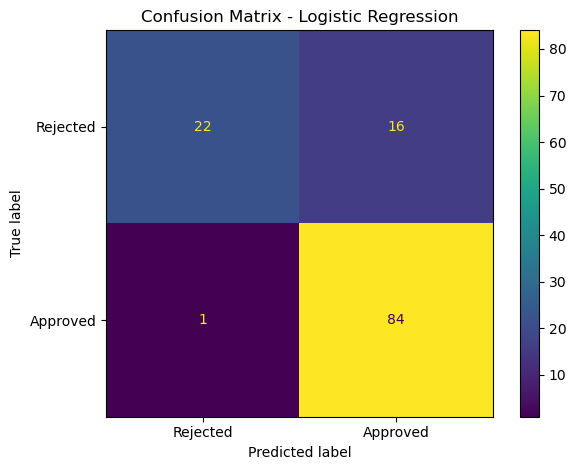

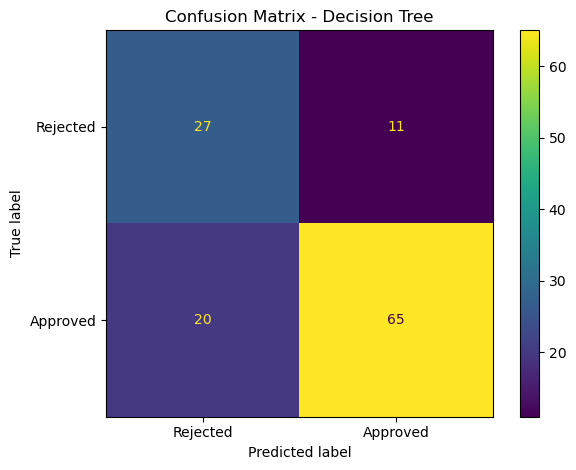

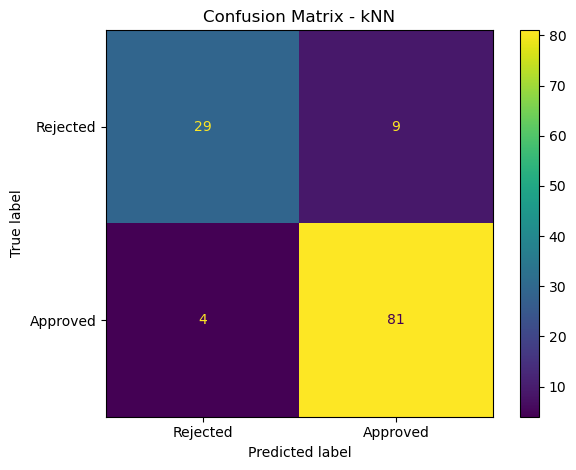

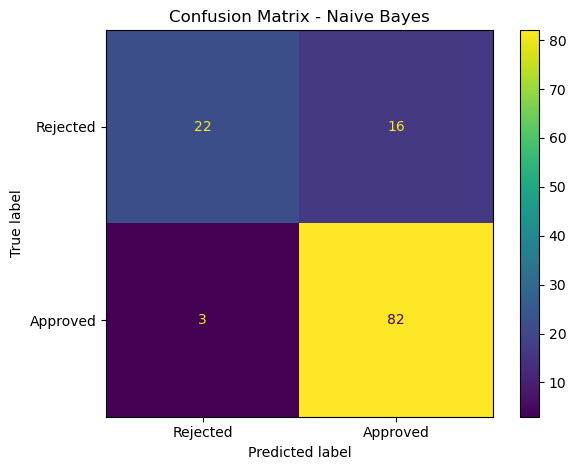

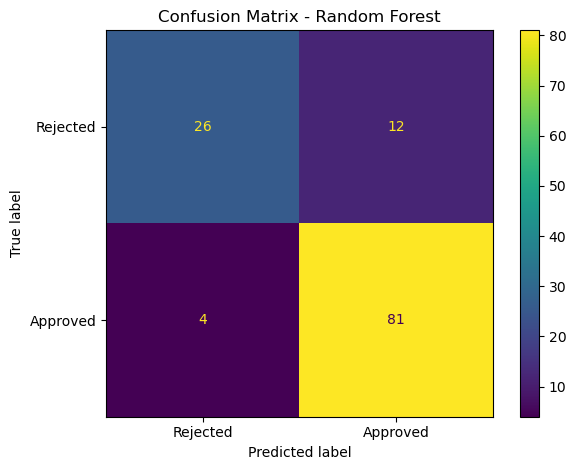

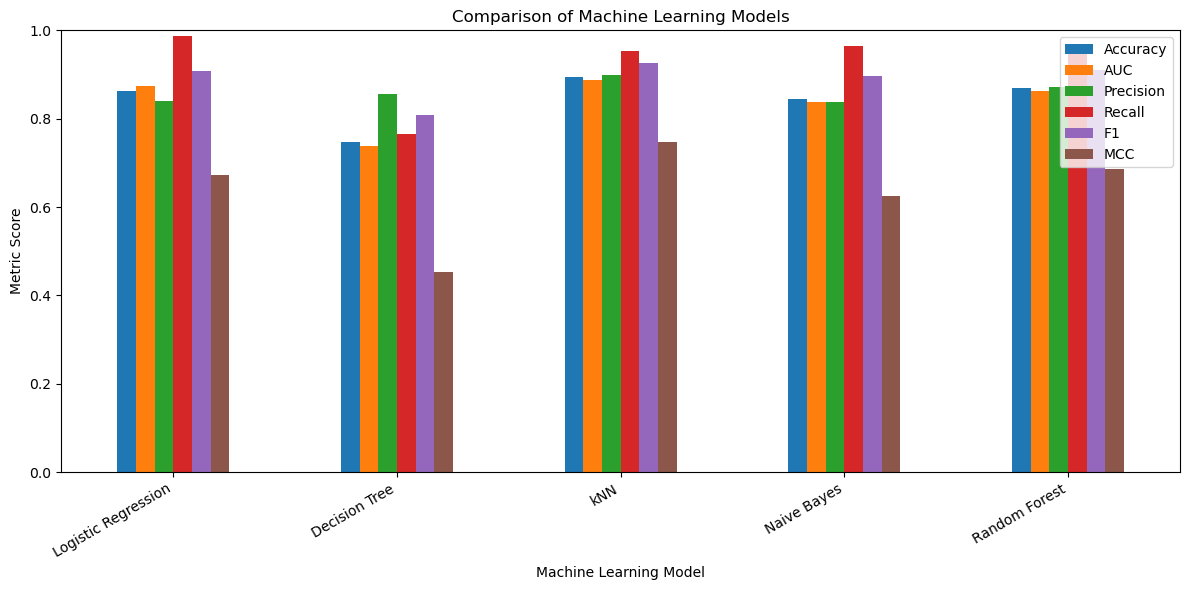


TRAINING COMPLETED SUCCESSFULLY

Files created:

1. model_comparison.csv
2. test_data.csv
3. model/logistic_regression.pkl
4. model/decision_tree.pkl
5. model/knn.pkl
6. model/naive_bayes.pkl
7. model/random_forest.pkl
8. model/feature_information.pkl



In [1]:
# ============================================================
# MACHINE LEARNING ASSIGNMENT - 2
# Loan Sanction Classification
#
# Dataset: loan_sanction.csv
#
# Objective:
# Predict whether a loan application will be Approved (Y)
# or Rejected (N) using multiple classification algorithms.
#
# Models:
# 1. Logistic Regression
# 2. Decision Tree
# 3. K-Nearest Neighbors (kNN)
# 4. Gaussian Naive Bayes
# 5. Random Forest
#
# Evaluation Metrics:
# Accuracy, AUC, Precision, Recall, F1 Score, MCC
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ignore unnecessary warning messages for cleaner output
warnings.filterwarnings("ignore")


# Scikit-learn utilities
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.base import clone


# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier


# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


# ------------------------------------------------------------
# 2. LOAD THE DATASET
# ------------------------------------------------------------

# Make sure loan_sanction.csv is present in the same directory
# as this Python file / notebook.
DATA_PATH = "loan_sanction.csv"

df = pd.read_csv(DATA_PATH)


# ------------------------------------------------------------
# 3. BASIC DATASET EXPLORATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
print(df.describe(include="all"))

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

print("\nTarget class distribution:")
print(df["Loan_Status"].value_counts())

print("\nTarget class distribution in percentage:")
print(
    df["Loan_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# ------------------------------------------------------------
# 4. FEATURE ENGINEERING
# ------------------------------------------------------------

# The original dataset has 11 meaningful predictor columns
# after excluding Loan_ID and Loan_Status.
#
# The assignment requires at least 12 features.
# Therefore, we create two meaningful additional features.

# Total household income
df["TotalIncome"] = (
    df["ApplicantIncome"] +
    df["CoapplicantIncome"]
)


# Ratio between requested loan amount and total household income
#
# replace(0, np.nan) protects against division by zero.
df["LoanAmount_to_TotalIncome"] = (
    df["LoanAmount"] /
    df["TotalIncome"].replace(0, np.nan)
)


print("\nNew engineered features created:")
print(
    df[
        [
            "ApplicantIncome",
            "CoapplicantIncome",
            "TotalIncome",
            "LoanAmount",
            "LoanAmount_to_TotalIncome"
        ]
    ].head()
)


# ------------------------------------------------------------
# 5. ENCODE THE TARGET VARIABLE
# ------------------------------------------------------------

# Original target:
# Y = Loan Approved
# N = Loan Rejected
#
# Convert it into numerical values:
# Y -> 1
# N -> 0

df["Loan_Status"] = df["Loan_Status"].map(
    {
        "N": 0,
        "Y": 1
    }
)


print("\nEncoded target distribution:")
print(df["Loan_Status"].value_counts())


# ------------------------------------------------------------
# 6. DEFINE FEATURES AND TARGET
# ------------------------------------------------------------

# Loan_ID is only an identifier.
# It does not represent applicant financial or demographic
# information, so we exclude it from the model.

X = df.drop(
    columns=[
        "Loan_ID",
        "Loan_Status"
    ]
)

y = df["Loan_Status"]


print("\nNumber of predictor features:")
print(X.shape[1])

print("\nPredictor feature names:")
print(X.columns.tolist())


# ------------------------------------------------------------
# 7. DEFINE NUMERICAL AND CATEGORICAL FEATURES
# ------------------------------------------------------------

numerical_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History",
    "TotalIncome",
    "LoanAmount_to_TotalIncome"
]


categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]


print("\nNumerical Features:")
for feature in numerical_features:
    print("-", feature)

print("\nCategorical Features:")
for feature in categorical_features:
    print("-", feature)


# ------------------------------------------------------------
# 8. CREATE NUMERICAL PREPROCESSING PIPELINE
# ------------------------------------------------------------

# Numerical missing values are replaced with median values.
#
# Median is preferred because income and loan-related variables
# may contain extreme values.
#
# StandardScaler transforms numerical features so that they
# approximately have mean = 0 and standard deviation = 1.
#
# Scaling is especially important for:
# - Logistic Regression
# - kNN

numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ------------------------------------------------------------
# 9. CREATE CATEGORICAL PREPROCESSING PIPELINE
# ------------------------------------------------------------

# Missing categorical values are replaced with the most
# frequently occurring category.
#
# OneHotEncoder converts categorical variables into numerical
# dummy variables.
#
# handle_unknown="ignore" prevents errors if the Streamlit
# test file contains a category not seen during training.
#
# sparse_output=False is used because GaussianNB requires
# dense input.

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ------------------------------------------------------------
# 10. COMBINE PREPROCESSING STEPS
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 11. TRAIN-TEST SPLIT
# ------------------------------------------------------------

# 80% of data is used for training.
# 20% is used for testing.
#
# random_state=42 ensures reproducibility.
#
# stratify=y maintains approximately the same Approved/Rejected
# class proportions in both training and testing datasets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\n" + "=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

print("Training feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())


# ------------------------------------------------------------
# 12. DEFINE THE FIVE MACHINE LEARNING MODELS
# ------------------------------------------------------------

models = {

    # Logistic Regression
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    # Decision Tree
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    # K-Nearest Neighbors
    "kNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    # Gaussian Naive Bayes
    "Naive Bayes": GaussianNB(),

    # Random Forest Ensemble
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}


# ------------------------------------------------------------
# 13. CREATE DIRECTORY FOR SAVED MODELS
# ------------------------------------------------------------

os.makedirs(
    "model",
    exist_ok=True
)


# ------------------------------------------------------------
# 14. CREATE CONTAINERS FOR RESULTS
# ------------------------------------------------------------

results = []

trained_models = {}

confusion_matrices = {}

classification_reports = {}


# ------------------------------------------------------------
# 15. TRAIN AND EVALUATE EVERY MODEL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MODEL TRAINING AND EVALUATION")
print("=" * 70)


for model_name, classifier in models.items():

    print("\n" + "-" * 70)
    print("MODEL:", model_name)
    print("-" * 70)

    # --------------------------------------------------------
    # Build a full pipeline:
    #
    # Raw Data
    #    ↓
    # Missing-value treatment
    #    ↓
    # Scaling / One-Hot Encoding
    #    ↓
    # Classification Model
    # --------------------------------------------------------

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "classifier",
                classifier
            )
        ]
    )


    # --------------------------------------------------------
    # Train the model
    # --------------------------------------------------------

    model_pipeline.fit(
        X_train,
        y_train
    )


    # --------------------------------------------------------
    # Generate class predictions
    # --------------------------------------------------------

    y_pred = model_pipeline.predict(
        X_test
    )


    # --------------------------------------------------------
    # Generate probability of positive class
    #
    # [:, 1] means probability of Class 1 = Approved
    # --------------------------------------------------------

    y_probability = model_pipeline.predict_proba(
        X_test
    )[:, 1]


    # --------------------------------------------------------
    # Calculate evaluation metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    auc = roc_auc_score(
        y_test,
        y_probability
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )


    # --------------------------------------------------------
    # Confusion Matrix
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred
    )


    # --------------------------------------------------------
    # Classification Report
    # --------------------------------------------------------

    report = classification_report(
        y_test,
        y_pred,
        target_names=[
            "Rejected",
            "Approved"
        ],
        output_dict=True,
        zero_division=0
    )


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    results.append(
        {
            "ML Model Name": model_name,
            "Accuracy": accuracy,
            "AUC": auc,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "MCC": mcc
        }
    )


    trained_models[model_name] = model_pipeline

    confusion_matrices[model_name] = cm

    classification_reports[model_name] = report


    # --------------------------------------------------------
    # Print metrics
    # --------------------------------------------------------

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"AUC       : {auc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"MCC       : {mcc:.4f}")


    print("\nConfusion Matrix:")
    print(cm)


    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Rejected",
                "Approved"
            ],
            zero_division=0
        )
    )


# ------------------------------------------------------------
# 16. CREATE MODEL COMPARISON TABLE
# ------------------------------------------------------------

results_df = pd.DataFrame(
    results
)


# Round metric values for cleaner presentation
results_df[
    [
        "Accuracy",
        "AUC",
        "Precision",
        "Recall",
        "F1",
        "MCC"
    ]
] = results_df[
    [
        "Accuracy",
        "AUC",
        "Precision",
        "Recall",
        "F1",
        "MCC"
    ]
].round(4)


print("\n" + "=" * 70)
print("MODEL COMPARISON TABLE")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 17. SAVE MODEL COMPARISON TABLE
# ------------------------------------------------------------

results_df.to_csv(
    "model_comparison.csv",
    index=False
)

print(
    "\nModel comparison table saved as:"
    "\nmodel_comparison.csv"
)


# ------------------------------------------------------------
# 18. FIND THE BEST MODEL
# ------------------------------------------------------------

# There is no universally correct definition of "best".
#
# Here we use F1 score as the main ranking metric because it
# balances precision and recall.
#
# We also review AUC and MCC in the final interpretation.

best_row = results_df.loc[
    results_df["F1"].idxmax()
]

best_model_name = best_row[
    "ML Model Name"
]


print("\n" + "=" * 70)
print("OVERALL WINNER")
print("=" * 70)

print(
    "Best model based on F1 Score:",
    best_model_name
)

print(
    "\nWinner's Metrics:"
)

print(best_row)


# ------------------------------------------------------------
# 19. SAVE ALL TRAINED MODELS
# ------------------------------------------------------------

# Each saved object contains:
#
# preprocessing + machine-learning model
#
# This is important because Streamlit can directly load the
# model and apply exactly the same preprocessing.

model_file_names = {
    "Logistic Regression":
        "model/logistic_regression.pkl",

    "Decision Tree":
        "model/decision_tree.pkl",

    "kNN":
        "model/knn.pkl",

    "Naive Bayes":
        "model/naive_bayes.pkl",

    "Random Forest":
        "model/random_forest.pkl"
}


for model_name, trained_model in trained_models.items():

    filename = model_file_names[
        model_name
    ]

    joblib.dump(
        trained_model,
        filename
    )

    print(
        f"Saved {model_name} -> {filename}"
    )


# ------------------------------------------------------------
# 20. CREATE TEST DATA CSV
# ------------------------------------------------------------

# The Streamlit application requires test data.
#
# We combine X_test and y_test so the uploaded CSV contains
# both predictors and the actual target.

test_data = X_test.copy()

test_data[
    "Loan_Status"
] = y_test.values


# Convert numerical target back into original labels
#
# 1 -> Y
# 0 -> N

test_data[
    "Loan_Status"
] = test_data[
    "Loan_Status"
].map(
    {
        1: "Y",
        0: "N"
    }
)


# Save the file
test_data.to_csv(
    "test_data.csv",
    index=False
)


print(
    "\nTest data saved as:"
    "\ntest_data.csv"
)


# ------------------------------------------------------------
# 21. SAVE FEATURE INFORMATION
# ------------------------------------------------------------

feature_information = {
    "numerical_features":
        numerical_features,

    "categorical_features":
        categorical_features,

    "target":
        "Loan_Status"
}


joblib.dump(
    feature_information,
    "model/feature_information.pkl"
)


# ------------------------------------------------------------
# 22. DISPLAY CONFUSION MATRICES
# ------------------------------------------------------------

for model_name, model_pipeline in trained_models.items():

    y_pred = model_pipeline.predict(
        X_test
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Rejected",
            "Approved"
        ]
    )

    display.plot()

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------
# 23. OPTIONAL: MODEL PERFORMANCE BAR CHART
# ------------------------------------------------------------

# This chart compares the models using all six required metrics.

metrics_for_plot = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1",
    "MCC"
]


results_df.set_index(
    "ML Model Name"
)[metrics_for_plot].plot(
    kind="bar",
    figsize=(12, 6)
)


plt.title(
    "Comparison of Machine Learning Models"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Metric Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 24. FINAL MESSAGE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAINING COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    """
Files created:

1. model_comparison.csv
2. test_data.csv
3. model/logistic_regression.pkl
4. model/decision_tree.pkl
5. model/knn.pkl
6. model/naive_bayes.pkl
7. model/random_forest.pkl
8. model/feature_information.pkl
"""
)